# <center>**Variance Swap Pricing under the Heston Model**</center>

This project involves pricing of a variance swap under the Heston model with closed-form formula and Monte Carlo methods. Similarly, the most relevant Greeks are obtained with closed-form formulas and finite difference scheme.

#### **Libraries**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (16,9)

#### **Parametrization**

Set the parameters for the Heston model:

In [2]:
S_0 = 120         # initial stock's price
r = 0.02          # risk-free rate
T = 1.0           # time to maturity (in years)
q = 0             # dividend rate
k = 3.0098        # variance mean-reversion speed
theta = 0.0580    # long-term variance mean
V_0 =  0.0844     # initial variance
sigma = 0.3204    # volatility of the instantaneous variance
rho = -0.2640     # correlation between stock's and variance's Brownian motions

In [3]:
dt = 1. / 252

In [4]:
No = 100000    # number of simulations

Below we calculate the fair strike realized variance under the Heston model. It is derived by finding a strike such that the expected value of any swap leg under the risk-neutral probability is equal to 0. Under the Heston model, the expected value of the realized variance, and therefore the fair strike as well, can be derived analytically.

In [5]:
K_var = 1 / (k * T) * (1 - np.exp(- k * T)) * (V_0 - theta) + theta     # fair strike under Heston
K_var

0.06633890603848502

Define few other strikes and the notional value of the swap:

In [6]:
K = K_var
K_1 = 0.9 * K
K_2 = 0.95 * K
K_3 = 1.05 * K
K_4 = 1.1 * K     
N = 1000000     # notional

#### **Pricing with closed-form formula**

Define the function calculating value for the swap payer (i.e., the price he pays), based on the analytical formula for the expected value of the realized variance under Heston:

In [7]:
def swap_pay_val(K):
  res = np.exp(- r * T) * N * (1 / (k * T) * (1 - np.exp(- k * T)) * (V_0 - theta) + theta - K)
  return res

In [8]:
swap_pay_val(K_1), swap_pay_val(K_2), swap_pay_val(K), swap_pay_val(K_3), swap_pay_val(K_4)

(6502.530768754452,
 3251.265384377226,
 0.0,
 -3251.265384377226,
 -6502.530768754452)

#### **Simulation of the stochastic processes**

Below we illustrate the simulation process for the purpose of pricing on a single example.

Brownian motions:

In [9]:
U = np.array([np.sqrt(dt) * np.random.normal() for i in range(int(252 * T) - 1)])
W = np.array([np.sqrt(dt) * np.random.normal() for i in range(int(252 * T) - 1)])

In [10]:
dB_S = U                                    # stock's Brownian Motion increments
dB_V = rho * U + np.sqrt(1 - rho**2) * W    # instantaneous variance's Brownian Motion increments

Instantaneous variance:

In [11]:
V = np.zeros(int(252 * T))
V[0] = V_0
for i in range(1, int(252 * T)):
  V[i] = V[i-1] + k * (theta - V[i-1]) * dt + sigma * np.sqrt(V[i-1]) * dB_V[i - 1]

Stock price:

In [12]:
S = np.zeros(int(252 * T))
S[0] = S_0
for i in range(1, int(252 * T)):
  S[i] = S[i-1] + (r - q) * S[i-1] * dt + np.sqrt(V[i-1]) * S[i-1] * dB_S[i - 1]

Figure:

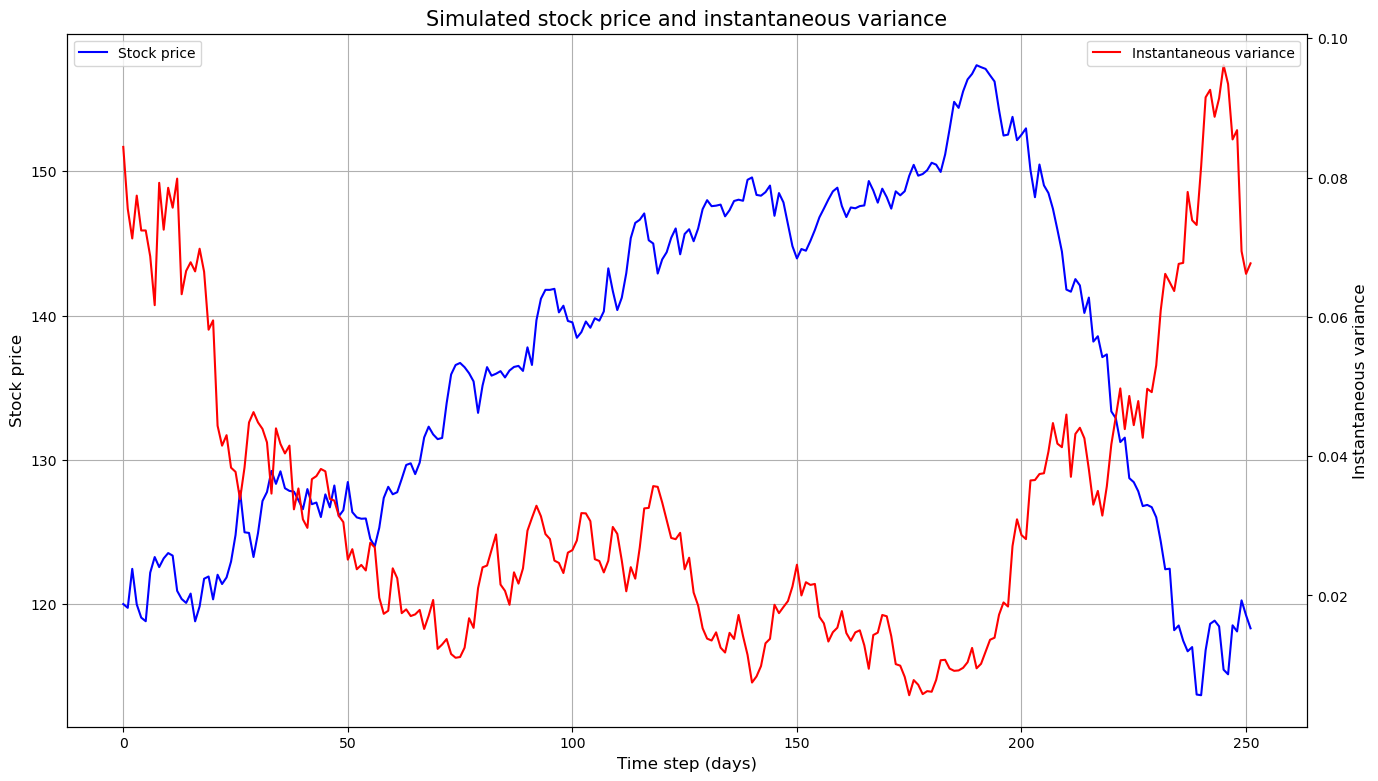

In [13]:
fig, ax = plt.subplots()
ax.plot(S, 'b', label = "Stock price")
ax2 = ax.twinx()
ax2.plot(V, 'r', label = "Instantaneous variance")
ax.set_xlabel("Time step (days)", size = 12)
ax.set_ylabel("Stock price", size = 12)
ax2.set_ylabel("Instantaneous variance", size = 12)
plt.title("Simulated stock price and instantaneous variance", size = 15)
ax.legend(loc = "upper left")
ax2.legend(loc = "upper right")
ax.grid()
plt.show()

Below we obtain the realized variance with two methods - directly taking the average variance simulated with Heston (first), and calculating the realized variance based on the simulated stock price, according to the standard formula used in variance swaps (second):

In [14]:
np.mean(V), 252 / (252 * T - 2) * np.sum([(np.log(S[i+1] / S[i])) ** 2 for i in range(len(S) - 1)])     

(0.03317938073563074, 0.02500220984915028)

#### **Monte Carlo simulation pricing**

Monte Carlo (MC) simulation pricing is performed by repeating the above steps many times. The realized variance obtained for each simulation with both methods is saved. The final price is equal to the average discounted payoff multiplied by the notional.

In [15]:
real_var_1 = np.zeros(No)     
real_var_2 = np.zeros(No)

for j in range(No):

  U = np.array([np.sqrt(dt) * np.random.normal() for i in range(int(252 * T) - 1)])
  W = np.array([np.sqrt(dt) * np.random.normal() for i in range(int(252 * T) - 1)])
  dB_S = U
  dB_V = rho * U + np.sqrt(1 - rho**2) * W
  
  V = np.zeros(int(252 * T))
  V[0] = V_0
  for i in range(1, int(252 * T)):
    V[i] = V[i-1] + k * (theta - V[i-1]) * dt + sigma * np.sqrt(V[i-1]) * dB_V[i - 1]
  
  S = np.zeros(int(252 * T))
  S[0] = S_0
  for i in range(1, int(252 * T)):
    S[i] = S[i-1] + (r - q) * S[i-1] * dt + np.sqrt(V[i-1]) * S[i-1] * dB_S[i - 1]  
  
  real_var_1[j] = np.mean(V)
  real_var_2[j] = 252 / (252 * T - 2) * np.sum([(np.log(S[i+1] / S[i])) ** 2 for i in range(len(S) - 1)])

C:\Users\wojci\AppData\Local\Temp\ipykernel_35316\3507793700.py:14: RuntimeWarning: invalid value encountered in sqrt
  V[i] = V[i-1] + k * (theta - V[i-1]) * dt + sigma * np.sqrt(V[i-1]) * dB_V[i - 1]
C:\Users\wojci\AppData\Local\Temp\ipykernel_35316\3507793700.py:19: RuntimeWarning: invalid value encountered in sqrt
  S[i] = S[i-1] + (r - q) * S[i-1] * dt + np.sqrt(V[i-1]) * S[i-1] * dB_S[i - 1]


In [16]:
price_1 = N * (np.nanmean(real_var_1) - K) * np.exp(- r * T)
price_2 = N * (np.nanmean(real_var_2) - K) * np.exp(- r * T)

In [17]:
price_1, price_2

(-61.98721186020247, 278.4037676572325)

#### **Prices comparison**

Below we compare the prices obtained with closed-form formula and the two MC methods for a range of strikes around the fair strike.

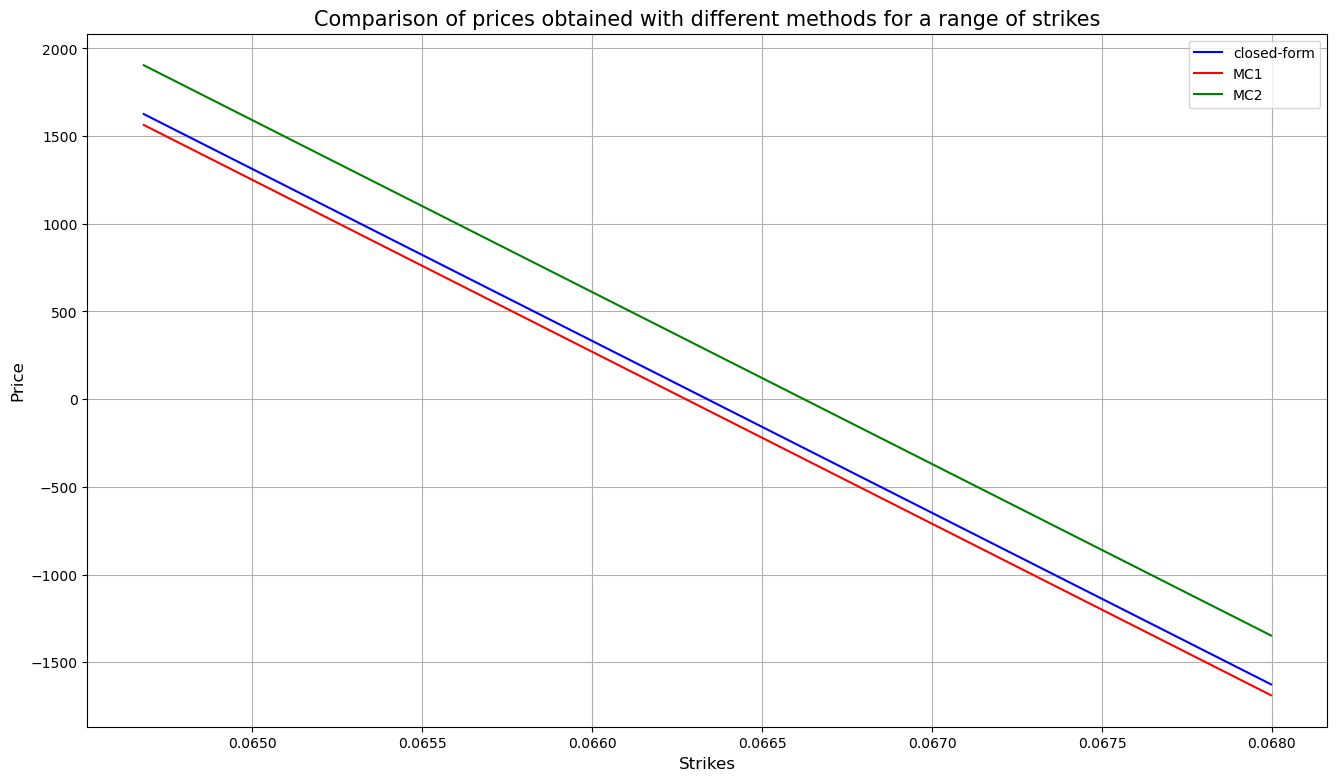

In [18]:
Ks = np.linspace(0.975 * K, 1.025 * K, 1000)
plt.plot(Ks, swap_pay_val(Ks), 'b', label = 'closed-form')
plt.plot(Ks, N * (np.nanmean(real_var_1) - Ks) * np.exp(- r * T), 'r', label = 'MC1')
plt.plot(Ks, N * (np.nanmean(real_var_2) - Ks) * np.exp(- r * T), 'g', label = 'MC2')
plt.xlabel("Strikes", size = 12)
plt.ylabel("Price", size = 12)
plt.title("Comparison of prices obtained with different methods for a range of strikes", size = 15)
plt.legend()
plt.grid()
plt.show()

#### **Greeks according to the closed-form formulas**

Below we calculate the values of selected Greeks by taking derivatives of the price with respect to the respective parameter.

Sensitivity to the initial variance (V_0):

In [19]:
np.exp(- r * T) * N * (1 / (k * T) * (1 - np.exp(- k * T)))

309613.0543845721

Sensitivity to the long-term average variance (theta):

In [20]:
np.exp(- r * T) * N * (1 - (1 / (k * T)) * (1 - np.exp(- k * T)))

670585.6189221832

#### **Finite difference scheme for key sensitivities of the price**

We compare the values of Greeks obtained with closed-form formulas with the values obtained via finite difference scheme. In order to obtain the latter, we shock the respective parameters upwards and downwards by a small amount, and simulate the paths of instantaneous variance as earlier. Then we obtain two corresponding prices of the swap, we take the difference between them, and divide by two times the mentioned amount.

Sensitivity to the initial variance (V_0):

In [21]:
h = 0.001

In [23]:
real_var_v0_up = np.zeros(No)
real_var_v0_down = np.zeros(No)      

for j in range(No):

  dB_V = np.array([np.sqrt(dt) * np.random.normal() for i in range(int(252 * T) - 1)])
  
  V_up = np.zeros(int(252 * T))
  V_up[0] = V_0 + h
  V_down = np.zeros(int(252 * T))
  V_down[0] = V_0 - h
  for i in range(1, int(252 * T)):
    V_up[i] = V_up[i-1] + k * (theta - V_up[i-1]) * dt + sigma * np.sqrt(V_up[i-1]) * dB_V[i - 1]
    V_down[i] = V_down[i-1] + k * (theta - V_down[i-1]) * dt + sigma * np.sqrt(V_down[i-1]) * dB_V[i - 1]
  
  real_var_v0_up[j] = np.mean(V_up)
  real_var_v0_down[j] = np.mean(V_down)

C:\Users\wojci\AppData\Local\Temp\ipykernel_35316\1434722466.py:13: RuntimeWarning: invalid value encountered in sqrt
  V_up[i] = V_up[i-1] + k * (theta - V_up[i-1]) * dt + sigma * np.sqrt(V_up[i-1]) * dB_V[i - 1]
C:\Users\wojci\AppData\Local\Temp\ipykernel_35316\1434722466.py:14: RuntimeWarning: invalid value encountered in sqrt
  V_down[i] = V_down[i-1] + k * (theta - V_down[i-1]) * dt + sigma * np.sqrt(V_down[i-1]) * dB_V[i - 1]


In [24]:
price_v0_up = N * (np.nanmean(real_var_v0_up) - K) * np.exp(- r * T)
price_v0_down = N * (np.nanmean(real_var_v0_down) - K) * np.exp(- r * T)

In [25]:
(price_v0_up - price_v0_down) / (2 * h)

310259.52297125204

Sensitivity to the long-term average variance (theta):

In [26]:
h = 0.001

In [27]:
real_var_theta_up = np.zeros(No)
real_var_theta_down = np.zeros(No)      

for j in range(No):

  dB_V = np.array([np.sqrt(dt) * np.random.normal() for i in range(int(252 * T) - 1)])
  
  V_up = np.zeros(int(252 * T))
  V_up[0] = V_0
  V_down = np.zeros(int(252 * T))
  V_down[0] = V_0
  for i in range(1, int(252 * T)):
    V_up[i] = V_up[i-1] + k * (theta + h - V_up[i-1]) * dt + sigma * np.sqrt(V_up[i-1]) * dB_V[i - 1]
    V_down[i] = V_down[i-1] + k * (theta - h - V_down[i-1]) * dt + sigma * np.sqrt(V_down[i-1]) * dB_V[i - 1]
  
  real_var_theta_up[j] = np.mean(V_up)
  real_var_theta_down[j] = np.mean(V_down)

C:\Users\wojci\AppData\Local\Temp\ipykernel_35316\547365788.py:13: RuntimeWarning: invalid value encountered in sqrt
  V_up[i] = V_up[i-1] + k * (theta + h - V_up[i-1]) * dt + sigma * np.sqrt(V_up[i-1]) * dB_V[i - 1]
C:\Users\wojci\AppData\Local\Temp\ipykernel_35316\547365788.py:14: RuntimeWarning: invalid value encountered in sqrt
  V_down[i] = V_down[i-1] + k * (theta - h - V_down[i-1]) * dt + sigma * np.sqrt(V_down[i-1]) * dB_V[i - 1]


In [28]:
price_theta_up = N * (np.nanmean(real_var_theta_up) - K) * np.exp(- r * T)
price_theta_down = N * (np.nanmean(real_var_theta_down) - K) * np.exp(- r * T)

In [29]:
(price_theta_up - price_theta_down) / (2 * h)

669174.5060545952